# DeepLabCut for your standard (single animal) projects!

Some useful links:

- [DeepLabCut's GitHub: github.com/DeepLabCut/DeepLabCut](https://github.com/DeepLabCut/DeepLabCut)
- [DeepLabCut's Documentation: User Guide for Single Animal projects](https://deeplabcut.github.io/DeepLabCut/docs/standardDeepLabCut_UserGuide.html)


This notebook illustrates how to use the cloud to:
- create a training set
- train a network
- evaluate a network
- create simple quality check plots
- analyze novel videos!

### This notebook assumes you already have a project folder with labeled data!

This notebook demonstrates the necessary steps to use DeepLabCut for your own project.

This shows the most simple code to do so, but many of the functions have additional features, so please check out the overview & the protocol paper!

Nath\*, Mathis\* et al.: Using DeepLabCut for markerless pose estimation during behavior across species. Nature Protocols, 2019.


Paper: https://www.nature.com/articles/s41596-019-0176-0

Pre-print: https://www.biorxiv.org/content/biorxiv/early/2018/11/24/476531.full.pdf


## First, go to "Runtime" ->"change runtime type"->select "Python3", and then select "GPU"

As the COLAB environments were updated to CUDA 12.X and Python 3.11, we need to install DeepLabCut and TensorFlow in a distinct way to get TensorFlow to connect to the GPU.

In [ ]:
# this will take a couple of minutes to install all the dependencies!
!pip install --pre deeplabcut

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 59.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 44.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible

**(Be sure to click "RESTART RUNTIME" if it is displayed above before moving on !)** You will see this button at the output of the cells above ^.

In [ ]:
import deeplabcut

## Link your Google Drive (with your labeled data, or the demo data):

### First, place your project folder into you google drive! "i.e. move the folder named "Project-YourName-TheDate" into google drive.

In [ ]:
# Now, let's link to your GoogleDrive. Run this cell and follow the authorization instructions:
# (We recommend putting a copy of the github repo in your google drive if you are using the demo "examples")

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


YOU WILL NEED TO EDIT THE PROJECT PATH **in the config.yaml file** TO BE SET TO YOUR GOOGLE DRIVE LINK!

Typically, this will be: `/content/drive/My Drive/yourProjectFolderName`


In [ ]:
# PLEASE EDIT THIS:
project_folder_name = "testStomatopodEyeTracking-SYP-2026-08-19"
video_type = "mp4"  # , mp4, MOV, or avi, whatever you uploaded!
# No need to edit this, we are going to assume you put videos you want to analyze
# in the "videos" folder, but if this is NOT true, edit below:
videofile_path = [f"/content/drive/MyDrive/{project_folder_name}/videos/"]
print(videofile_path)

# The prediction files and labeled videos will be saved in this `labeled-videos` folder
# in your project folder; if you want them elsewhere, you can edit this;
# if you want the output files in the same folder as the videos, set this to an empty string.
destfolder = f"/content/drive/MyDrive/{project_folder_name}/labeled-videos"

# No need to edit this, as you set it when you passed the ProjectFolderName (above):
path_config_file = f"/content/drive/MyDrive/{project_folder_name}/config.yaml"
print(path_config_file)

# This creates a path variable that links to your Google Drive project

['/content/drive/MyDrive/FolderName/videos/']
/content/drive/MyDrive/FolderName/config.yaml


In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
scorer = 'SYP'

# Ensure this matches the exact list in your config.yaml (we dropped stalk_base!)
bodyparts = [
    'L_midband_dorsal', 'L_midband_ventral', 'L_eyestalk_peduncle', 'L_stalk_base',
    'R_midband_dorsal', 'R_midband_ventral', 'R_eyestalk_peduncle', 'R_stalk_base'
]

folder_name = 'stomatopod'
xml_file =  '/content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/annotations.xml'# Your uploaded CVAT file
csv_output = f'/content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/labeled-data/{folder_name}/CollectedData_{scorer}.csv'
# ---------------------

tree = ET.parse(xml_file)
root = tree.getroot()

# Create the DeepLabCut MultiIndex headers
columns = pd.MultiIndex.from_product(
    [[scorer], bodyparts, ['x', 'y']],
    names=['scorer', 'bodyparts', 'coords']
)

df = pd.DataFrame(columns=columns)

# Parse the CVAT coordinates
for image in root.findall('image'):
    # DeepLabCut needs the relative image path
    img_name = f"labeled-data/{folder_name}/" + image.get('name')
    row_data = {bp: {'x': np.nan, 'y': np.nan} for bp in bodyparts}

    for points in image.findall('points'):
        label = points.get('label')
        if label in bodyparts:
            coords = points.get('points').split(',')
            row_data[label]['x'] = float(coords[0])
            row_data[label]['y'] = float(coords[1])

    # Flatten the row for pandas
    flat_row = []
    for bp in bodyparts:
        flat_row.extend([row_data[bp]['x'], row_data[bp]['y']])

    df.loc[img_name] = flat_row

# Save it directly to your Drive folder!
df.to_csv(csv_output)
print(f"Success! Converted {len(df)} frames and saved CSV to your Drive.")

Success! Converted 20 frames and saved CSV to your Drive.


In [ ]:
import pandas as pd
from pathlib import Path

# Paths
csv_path = Path('/content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/labeled-data/stomatopod/CollectedData_SYP.csv')
h5_path = csv_path.with_suffix('.h5')

# Read CSV and export to HDF5
df = pd.read_csv(csv_path, header=[0, 1, 2], index_col=0)
df.to_hdf(str(h5_path), key='df_with_missing', mode='w')

print(f"H5 file created successfully: {h5_path}")

H5 file created successfully: /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/labeled-data/stomatopod/CollectedData_SYP.h5


In [ ]:
import deeplabcut
config_path = '/content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/config.yaml'

deeplabcut.check_labels(config_path)

Creating images with labels by SYP.


100%|██████████| 20/20 [00:02<00:00,  8.74it/s]

If all the labels are ok, then use the function 'create_training_dataset' to create the training dataset!


In [ ]:
# I used CVAT instead of DLC GUI for labeling. so this code was not used.
deeplabcut.label_frames(config_path)

## Create a training dataset:

### You must do this step inside of Colab

After running this script the training dataset is created and saved in the project directory under the subdirectory **'training-datasets'**

This function also creates new subdirectories under **dlc-models-pytorch** and appends the project config.yaml file with the correct path to the training and testing pose configuration file. These files hold the parameters for training the network. Such an example file is provided with the toolbox and named as **pytorch_config.yaml**.

Now it is the time to start training the network!

In [ ]:
# There are many more functions you can set here, including which network to use!
# Check the docstring for `create_training_dataset` for all options you can use!

deeplabcut.create_training_dataset(path_config_file, net_type="resnet_50", engine=deeplabcut.Engine.PYTORCH)

[(0.95,
  1,
  (array([11,  1, 18, 17,  2, 12, 19, 16, 10,  0,  3,  4, 15,  8, 13,  9,  5,
          14,  7]),
   array([6])))]

## Start training:
This function trains the network for a specific shuffle of the training dataset.

In [ ]:
# Let's also change the display and save_epochs just in case Colab takes away
# the GPU... If that happens, you can reload from a saved point using the
# `snapshot_path` argument to `deeplabcut.train_network`:
#   deeplabcut.train_network(..., snapshot_path="/content/.../snapshot-050.pt")

# Typically, you want to train to ~200 epochs. We set the batch size to 8 to
# utilize the GPU's capabilities.

# More info and there are more things you can set:
#   https://deeplabcut.github.io/DeepLabCut/docs/standardDeepLabCut_UserGuide.html#g-train-the-network

deeplabcut.train_network(
    path_config_file,
    shuffle=1,
    save_epochs=5,
    epochs=200,
    batch_size=8,
)

# This will run until you stop it (CTRL+C), or hit "STOP" icon, or when it hits the end.

Training with configuration:
config_version: 0
model: backbone={'type': 'ResNet', 'model_name': 'resnet50_gn', 'output_stride': 16, 'freeze_bn_stats': False, 'freeze_bn_weights': False} heads={'bodypart': {'type': 'HeatmapHead', 'weight_init': 'normal', 'predictor': {'type': 'HeatmapPredictor', 'apply_sigmoid': False, 'clip_scores': True, 'location_refinement': True, 'locref_std': 7.2801}, 'target_generator': {'type': 'HeatmapGaussianGenerator', 'num_heatmaps': 8, 'pos_dist_thresh': 17, 'heatmap_mode': 'KEYPOINT', 'gradient_masking': False, 'generate_locref': True, 'locref_std': 7.2801}, 'criterion': {'heatmap': {'type': 'WeightedMSECriterion', 'weight': 1.0}, 'locref': {'type': 'WeightedHuberCriterion', 'weight': 0.05}}, 'heatmap_config': {'channels': [2048, 8], 'kernel_size': [3], 'strides': [2]}, 'locref_config': {'channels': [2048, 16], 'kernel_size': [3], 'strides': [2]}}} backbone_output_channels=2048 neck=None pose_model=None
net_type: NetType.RESNET_50
method: MethodType.BOTTOM

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

[timm/resnet50_gn.a1h_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
Data Transforms:
  Training:   Compose([
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (0.5, 1.25), 'y': (0.5, 1.25)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  PadIfNeeded(always_apply=True, p=1.0, min_height=448, min_width=448, pad_height_divisor=None, pad_width_divisor=None, position=PositionType.CENTER, border_mode=0, value=None, mask_value=None),
  KeypointAwareCrop(always_apply=True, p=1.0, width=448, height=448, max_shift=0.1, crop_sampling='hybrid'),
  MotionBlur(always_apply=False, p=0.5, blur_limit=(3, 7), allow_shifted=True),
  GaussNoise(always_apply=False, p=0.5, var_limit=(0, 162.5625), per_channel=True, mean=0),
  Nor

Note, that **when you hit "STOP" you will get a `KeyboardInterrupt` "error"! No worries! :)**

## Start evaluating:
This function evaluates a trained model for a specific shuffle/shuffles at a particular state or all the states on the data set (images)
and stores the results as .csv file in a subdirectory under **evaluation-results-pytorch**

In [ ]:
deeplabcut.evaluate_network(path_config_file, plotting=True)

# Here you want to see a low pixel error! Of course, it can only be as
# good as the labeler, so be sure your labels are good!

Evaluation scorer: DLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30


100%|██████████| 1/1 [00:00<00:00, 33.59it/s]


Evaluation results file: DLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30-results.csv
Evaluation results for DLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30-results.csv (pcutoff: 0.6):
train rmse              2.74
train rmse_pcutoff      2.57
train mAP             100.00
train mAR             100.00
test rmse               3.44
test rmse_pcutoff       3.72
test mAP              100.00
test mAR              100.00
Name: (0.95, 1, 30, -1, 0.6), dtype: float64
  Expected: 2 individuals, 8 bodyparts
  Ground truth: 16 elements (expected 32)
  Predictions: 24 elements (expected 48)
  Skipping visualization for this image
  Expected: 2 individuals, 8 bodyparts
  Ground truth: 16 elements (expected 32)
  Predictions: 24 elements (expected 48)
  Skipping visualization for this image
  Expected: 2 individuals, 8 bodyparts
  Ground truth: 16 elements (expected 32)
  Predictions: 24 elements (expected 48)
  Skipping visualization for this image
  Expected:

## There is an optional refinement step you can do outside of Colab:
- if your pixel errors are not low enough, please check out the protocol guide on how to refine your network!
- You will need to adjust the labels **outside of Colab!** We recommend coming back to train and analyze videos...
- Please see the repo and protocol instructions on how to refine your data!

## Start Analyzing videos:
This function analyzes the new video. The user can choose the best model from the evaluation results and specify the correct snapshot index for the variable **snapshotindex** in the **config.yaml** file. Otherwise, by default the most recent snapshot is used to analyse the video.

The results are stored in hd5 file in the same directory where the video resides.

In [ ]:
deeplabcut.analyze_videos(
    path_config_file,
    videofile_path,
    videotype=video_type,
    destfolder=destfolder,
)

Analyzing videos with /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/dlc-models-pytorch/iteration-0/testStomatopodEyeTrackingAug19-trainset95shuffle1/train/snapshot-best-030.pt
Using scorer: DLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30
Starting to analyze /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/videos/stomatopod.mp4
Video metadata: 
  Overall # of frames:    2367
  Duration of video [s]:  78.98
  fps:                    29.97
  resolution:             w=640, h=360

Running pose prediction with batch size 8


100%|██████████| 2367/2367 [00:48<00:00, 48.73it/s]


Saving results in /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/labeled-videos/stomatopodDLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30.h5 and /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/labeled-videos/stomatopodDLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30'

## Plot the trajectories of the analyzed videos:
This function plots the trajectories of all the body parts across the entire video. Each body part is identified by a unique color.

/tmp/ipykernel_9746/2603120072.py:1: DLCDeprecationWarning: Parameter 'videotype' of plot_trajectories is deprecated since 3.0.0; use 'video_extensions' instead.
  deeplabcut.plot_trajectories(
/usr/local/lib/python3.13/dist-packages/deeplabcut/utils/auxiliaryfunctions.py:643: UserWarning: Some videos have unsupported extensions: [PosixPath('/content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/labeled-videos/stomatopodDLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30.h5')] 
Supported extensions are: ('avi', 'mp4', 'mov', 'mpeg', 'mpg', 'mpv', 'mkv', 'flv', 'qt', 'yuv')
  for file in collect_video_paths(folder, extensions=".h5"):


Loading  /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/videos/stomatopod.mp4 and data.
Plots created! Please check the directory "plot-poses" within the video directory


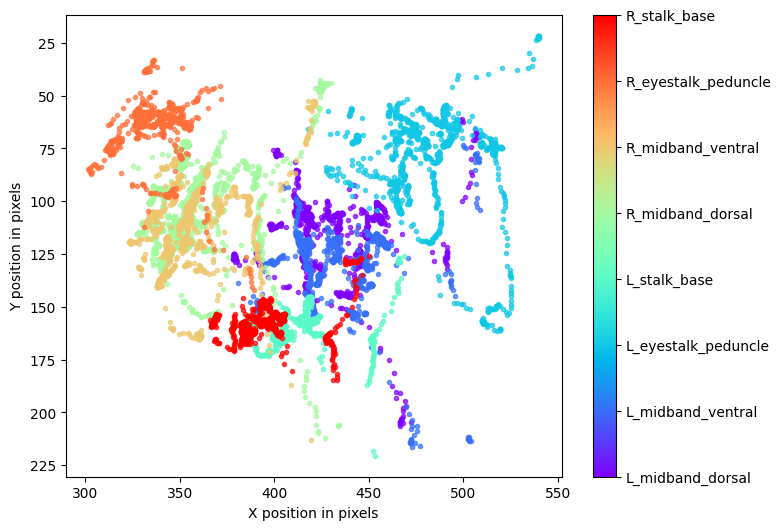

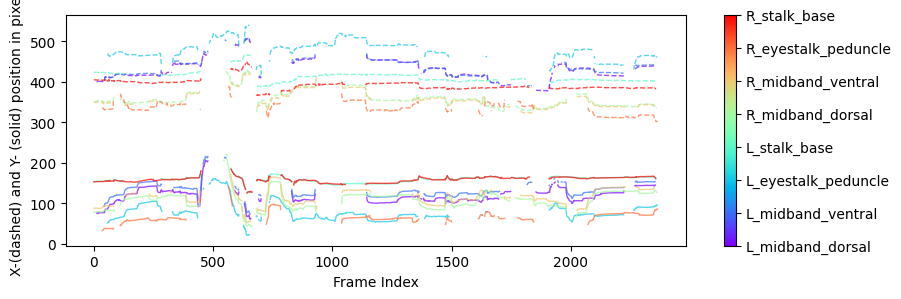

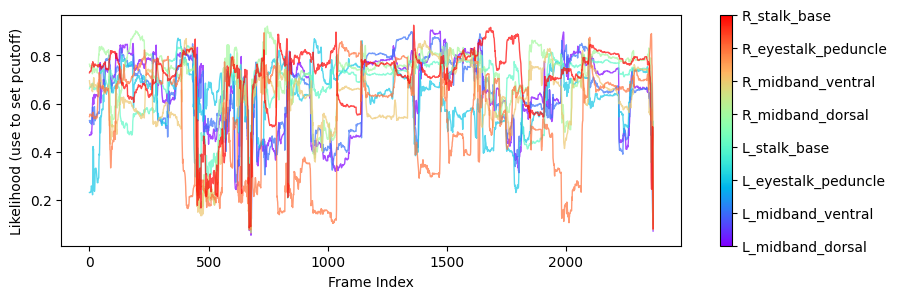

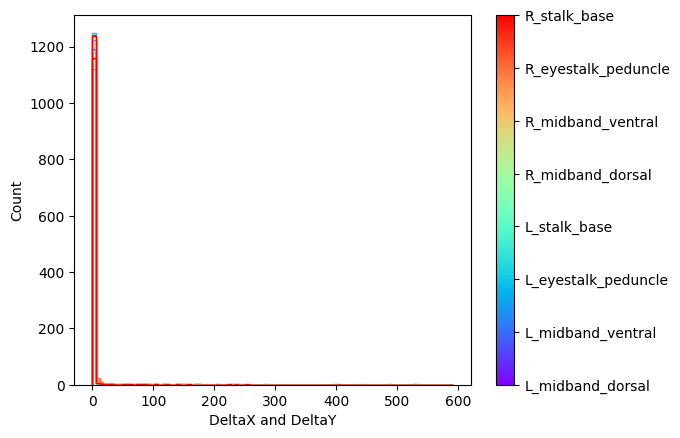

In [ ]:
deeplabcut.plot_trajectories(
    path_config_file,
    videofile_path,
    videotype=video_type,
    destfolder=destfolder,
)

Now you can look at the plot-poses file and check the "plot-likelihood.png" might want to change the "p-cutoff" in the config.yaml file so that you have only high confidnece points plotted in the video. i.e. ~0.8 or 0.9. The current default is 0.4.

## Create labeled video:
This function is for visualization purpose and can be used to create a video in .mp4 format with labels predicted by the network. This video is saved in the same directory where the original video resides.

In [ ]:
deeplabcut.create_labeled_video(
    path_config_file,
    videofile_path,
    videotype=video_type,
    destfolder=destfolder,
)

/tmp/ipykernel_9746/2802197778.py:1: DLCDeprecationWarning: Parameter 'videotype' of create_labeled_video is deprecated since 3.0.0; use 'video_extensions' instead.
  deeplabcut.create_labeled_video(


Starting to process video: /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/videos/stomatopod.mp4
Loading /content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/videos/stomatopod.mp4 and data.


/usr/local/lib/python3.13/dist-packages/deeplabcut/utils/auxiliaryfunctions.py:643: UserWarning: Some videos have unsupported extensions: [PosixPath('/content/drive/MyDrive/testStomatopodEyeTracking-SYP-2026-08-19/labeled-videos/stomatopodDLC_Resnet50_testStomatopodEyeTrackingAug19shuffle1_snapshot_best-30.h5')] 
Supported extensions are: ('avi', 'mp4', 'mov', 'mpeg', 'mpg', 'mpv', 'mkv', 'flv', 'qt', 'yuv')
  for file in collect_video_paths(folder, extensions=".h5"):


Duration of video [s]: 78.98, recorded with 29.97 fps!
Overall # of frames: 2367 with cropped frame dimensions: 640 360
Generating frames and creating video.


100%|██████████| 2367/2367 [00:06<00:00, 344.38it/s]


[True]